In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Data Analysis Dataset/OnlineRetail.csv", encoding='ISO-8859-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [ ]:
df.shape

(541909, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [ ]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
df = df.dropna(subset=['CustomerID'])

In [ ]:
df['CustomerID'] = df['CustomerID'].astype(str)

In [ ]:
df = df[df['Quantity'] > 0]

In [ ]:
df = df[df['UnitPrice'] > 0]

In [ ]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [ ]:
df['Country'].value_counts().head(10)

,count
Country,
United Kingdom,354321
Germany,9040
France,8341
EIRE,7236
Spain,2484
Netherlands,2359
Belgium,2031
Switzerland,1841
Portugal,1462


In [ ]:
df['Description'].value_counts().head(10)

,count
Description,
WHITE HANGING HEART T-LIGHT HOLDER,2028
REGENCY CAKESTAND 3 TIER,1723
JUMBO BAG RED RETROSPOT,1618
ASSORTED COLOUR BIRD ORNAMENT,1408
PARTY BUNTING,1396
LUNCH BAG RED RETROSPOT,1316
SET OF 3 CAKE TINS PANTRY DESIGN,1159
LUNCH BAG BLACK SKULL.,1105
POSTAGE,1099


In [ ]:
country_revenue = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)

country_revenue.head(10)

,TotalPrice
Country,
United Kingdom,7308391.554
Netherlands,285446.340
EIRE,265545.900
Germany,228867.140
France,209024.050
Australia,138521.310
Spain,61577.110
Switzerland,56443.950
Belgium,41196.340


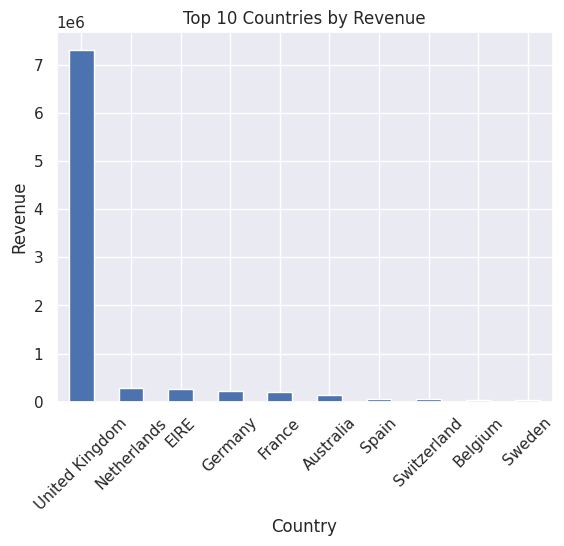

In [ ]:
plt.figure()
country_revenue.head(10).plot(kind='bar')
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [ ]:
customer_spending = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False)

customer_spending.head()

,TotalPrice
CustomerID,
14646.0,280206.02
18102.0,259657.30
17450.0,194550.79
16446.0,168472.50
14911.0,143825.06


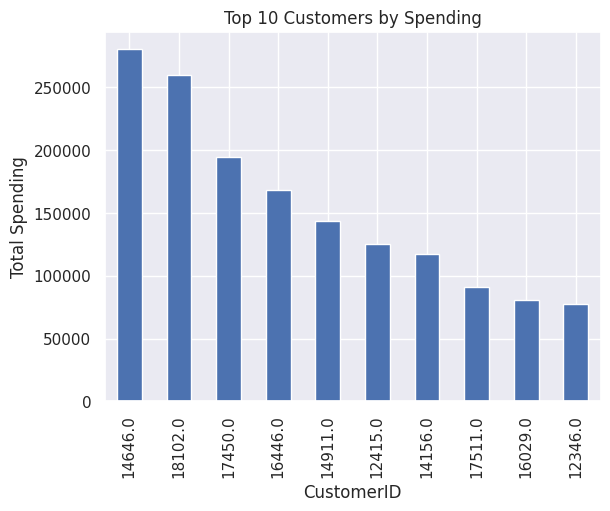

In [ ]:
plt.figure()
customer_spending.head(10).plot(kind='bar')
plt.title("Top 10 Customers by Spending")
plt.xlabel("CustomerID")
plt.ylabel("Total Spending")
plt.show()

In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%d-%m-%Y %H:%M')

In [ ]:
df['Month'] = df['InvoiceDate'].dt.month

In [ ]:
monthly_revenue = df.groupby('Month')['TotalPrice'].sum()

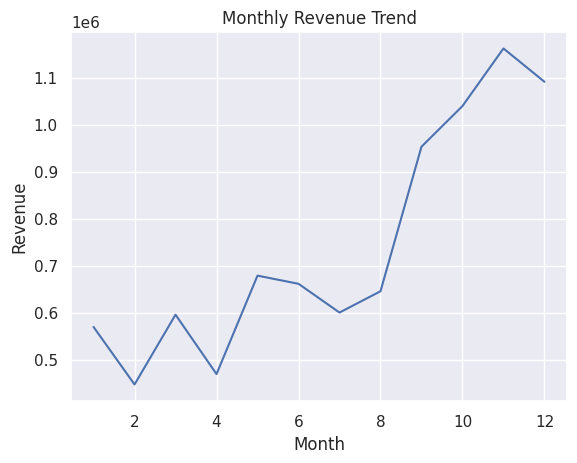

In [ ]:
plt.figure()
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [ ]:
product_revenue = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False)

product_revenue.head(10)

,TotalPrice
Description,
"PAPER CRAFT , LITTLE BIRDIE",168469.60
REGENCY CAKESTAND 3 TIER,142592.95
WHITE HANGING HEART T-LIGHT HOLDER,100448.15
JUMBO BAG RED RETROSPOT,85220.78
MEDIUM CERAMIC TOP STORAGE JAR,81416.73
POSTAGE,77803.96
PARTY BUNTING,68844.33
ASSORTED COLOUR BIRD ORNAMENT,56580.34
Manual,53779.93


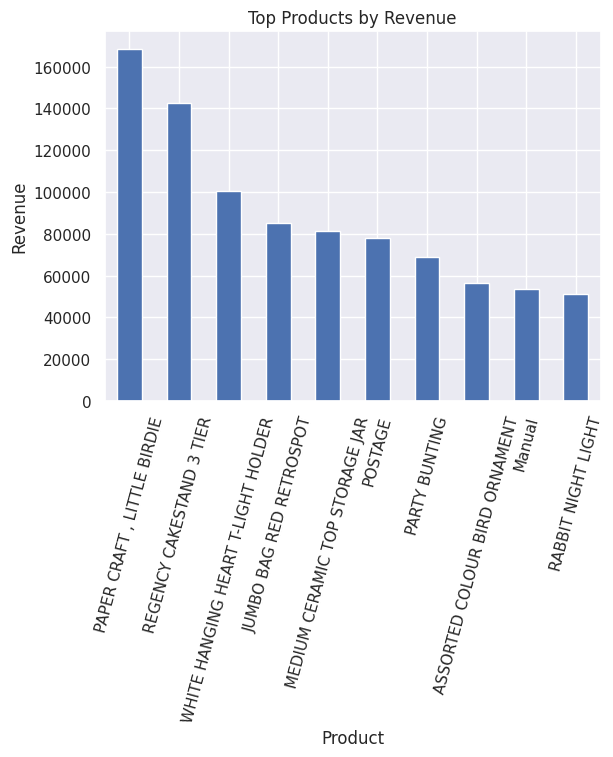

In [ ]:
plt.figure()
product_revenue.head(10).plot(kind='bar')
plt.title("Top Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=75)
plt.show()

In [ ]:
df[['Quantity', 'UnitPrice', 'TotalPrice']].corr()

,Quantity,UnitPrice,TotalPrice
Quantity,1.000000,-0.004563,0.914387
UnitPrice,-0.004563,1.000000,0.081645
TotalPrice,0.914387,0.081645,1.000000


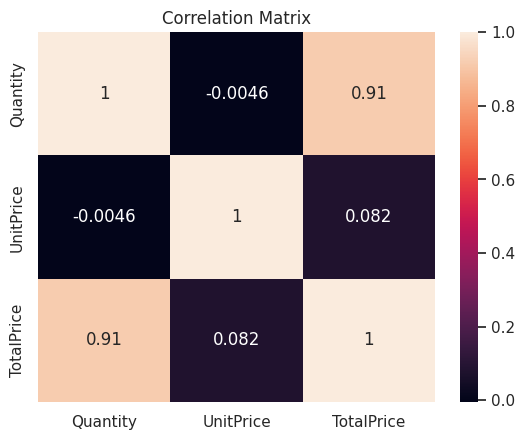

In [ ]:
sns.heatmap(df[['Quantity', 'UnitPrice', 'TotalPrice']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
# Now what we conclude from this data:

# 1. Revenue is super concentrated in a few places (mostly the UK).
# #Therefore: We should double down on the UK market to keep our core strong before trying to go too big elsewhere.

# 2. A tiny group of "big spender" customers is carrying a huge chunk of the revenue.
# #Therefore: We need to treat these VIPs like gold. A loyalty program or direct outreach would go a long way in keeping them around.

# 3. A handful of "hero" products are doing the heavy lifting for our sales.
# #Therefore: We should lead our marketing with these winners and try bundling them with slower-moving items to clear stock.

# 4. There's a clear seasonal pattern, with things really picking up toward the end of the year.
# #Therefore: We need to have our inventory and extra help ready by late summer so we don't miss out on that Q4 rush.

# 5. Volume is the real engine here, selling more units moves the needle much more than just raising prices.
# #Therefore: Focus on "buy more, save more" deals to get people to fill their carts, rather than hiking up individual prices.